In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
df = pd.read_csv(
    r"D:\Ai_project\AI_Sales_Prediction_Dashboard\data\sales.csv"
)

In [4]:
df.head()

,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,category,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year
0,AG-2011-2040,1/1/2011,6/1/2011,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,...,Office Supplies,Storage,"Tenex Lockers, Blue",408,2,0.0,106.140,35.46,Medium,2011
1,IN-2011-47883,1/1/2011,8/1/2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Office Supplies,Supplies,"Acme Trimmer, High Speed",120,3,0.1,36.036,9.72,Medium,2011
2,HU-2011-1220,1/1/2011,5/1/2011,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,...,Office Supplies,Storage,"Tenex Box, Single Width",66,4,0.0,29.640,8.17,High,2011
3,IT-2011-3647632,1/1/2011,5/1/2011,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,...,Office Supplies,Paper,"Enermax Note Cards, Premium",45,3,0.5,-26.055,4.82,High,2011
4,IN-2011-47883,1/1/2011,8/1/2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Furniture,Furnishings,"Eldon Light Bulb, Duo Pack",114,5,0.1,37.770,4.70,Medium,2011


In [5]:
df.shape

(51290, 21)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   order_id        51290 non-null  str    
 1   order_date      51290 non-null  str    
 2   ship_date       51290 non-null  str    
 3   ship_mode       51290 non-null  str    
 4   customer_name   51290 non-null  str    
 5   segment         51290 non-null  str    
 6   state           51290 non-null  str    
 7   country         51290 non-null  str    
 8   market          51290 non-null  str    
 9   region          51290 non-null  str    
 10  product_id      51290 non-null  str    
 11  category        51290 non-null  str    
 12  sub_category    51290 non-null  str    
 13  product_name    51290 non-null  str    
 14  sales           51290 non-null  str    
 15  quantity        51290 non-null  int64  
 16  discount        51290 non-null  float64
 17  profit          51290 non-null  float64
 1

In [7]:
df.describe()

,quantity,discount,profit,shipping_cost,year
count,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000
mean,3.476545,0.142908,28.641740,26.375915,2012.777208
std,2.278766,0.212280,174.424113,57.296804,1.098931
min,1.000000,0.000000,-6599.978000,0.000000,2011.000000
25%,2.000000,0.000000,0.000000,2.610000,2012.000000
50%,3.000000,0.000000,9.240000,7.790000,2013.000000
75%,5.000000,0.200000,36.810000,24.450000,2014.000000
max,14.000000,0.850000,8399.976000,933.570000,2014.000000


In [8]:
df.columns

Index(['order_id', 'order_date', 'ship_date', 'ship_mode', 'customer_name',
       'segment', 'state', 'country', 'market', 'region', 'product_id',
       'category', 'sub_category', 'product_name', 'sales', 'quantity',
       'discount', 'profit', 'shipping_cost', 'order_priority', 'year'],
      dtype='str')

In [9]:
df.isnull().sum()

order_id          0
order_date        0
ship_date         0
ship_mode         0
customer_name     0
segment           0
state             0
country           0
market            0
region            0
product_id        0
category          0
sub_category      0
product_name      0
sales             0
quantity          0
discount          0
profit            0
shipping_cost     0
order_priority    0
year              0
dtype: int64

In [10]:
df["order_date"] = pd.to_datetime(
    df["order_date"],
    format="mixed",
    errors="coerce"
)

In [11]:
df["ship_date"] = pd.to_datetime(
    df["ship_date"],
    format="mixed",
    errors="coerce"
)

In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   order_id        51290 non-null  str           
 1   order_date      51290 non-null  datetime64[us]
 2   ship_date       51290 non-null  datetime64[us]
 3   ship_mode       51290 non-null  str           
 4   customer_name   51290 non-null  str           
 5   segment         51290 non-null  str           
 6   state           51290 non-null  str           
 7   country         51290 non-null  str           
 8   market          51290 non-null  str           
 9   region          51290 non-null  str           
 10  product_id      51290 non-null  str           
 11  category        51290 non-null  str           
 12  sub_category    51290 non-null  str           
 13  product_name    51290 non-null  str           
 14  sales           51290 non-null  str           
 15  quantity     

In [13]:
df["year"] = df["order_date"].dt.year

df["month"] = df["order_date"].dt.month

df["month_name"] = df["order_date"].dt.month_name()

df["day"] = df["order_date"].dt.day

df["day_of_week"] = df["order_date"].dt.day_name()

df["quarter"] = df["order_date"].dt.quarter

In [14]:
df.head()

,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,discount,profit,shipping_cost,order_priority,year,month,month_name,day,day_of_week,quarter
0,AG-2011-2040,2011-01-01,2011-06-01,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,...,0.0,106.140,35.46,Medium,2011,1,January,1,Saturday,1
1,IN-2011-47883,2011-01-01,2011-08-01,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,0.1,36.036,9.72,Medium,2011,1,January,1,Saturday,1
2,HU-2011-1220,2011-01-01,2011-05-01,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,...,0.0,29.640,8.17,High,2011,1,January,1,Saturday,1
3,IT-2011-3647632,2011-01-01,2011-05-01,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,...,0.5,-26.055,4.82,High,2011,1,January,1,Saturday,1
4,IN-2011-47883,2011-01-01,2011-08-01,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,0.1,37.770,4.70,Medium,2011,1,January,1,Saturday,1


In [15]:
df["sales"].dtype

<StringDtype(na_value=nan)>

In [16]:
df["sales"] = (
    df["sales"]
    .astype(str)
    .str.replace(",", "", regex=False)
)

df["sales"] = pd.to_numeric(
    df["sales"],
    errors="coerce"
)

In [17]:
df["sales"].dtype

dtype('int64')

In [18]:
df["sales"].head()

0    408
1    120
2     66
3     45
4    114
Name: sales, dtype: int64

In [19]:
df["revenue"] = df["sales"]

In [20]:
df.head()

,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,profit,shipping_cost,order_priority,year,month,month_name,day,day_of_week,quarter,revenue
0,AG-2011-2040,2011-01-01,2011-06-01,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,...,106.140,35.46,Medium,2011,1,January,1,Saturday,1,408
1,IN-2011-47883,2011-01-01,2011-08-01,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,36.036,9.72,Medium,2011,1,January,1,Saturday,1,120
2,HU-2011-1220,2011-01-01,2011-05-01,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,...,29.640,8.17,High,2011,1,January,1,Saturday,1,66
3,IT-2011-3647632,2011-01-01,2011-05-01,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,...,-26.055,4.82,High,2011,1,January,1,Saturday,1,45
4,IN-2011-47883,2011-01-01,2011-08-01,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,37.770,4.70,Medium,2011,1,January,1,Saturday,1,114


In [21]:
df.isnull().sum()

order_id          0
order_date        0
ship_date         0
ship_mode         0
customer_name     0
segment           0
state             0
country           0
market            0
region            0
product_id        0
category          0
sub_category      0
product_name      0
sales             0
quantity          0
discount          0
profit            0
shipping_cost     0
order_priority    0
year              0
month             0
month_name        0
day               0
day_of_week       0
quarter           0
revenue           0
dtype: int64

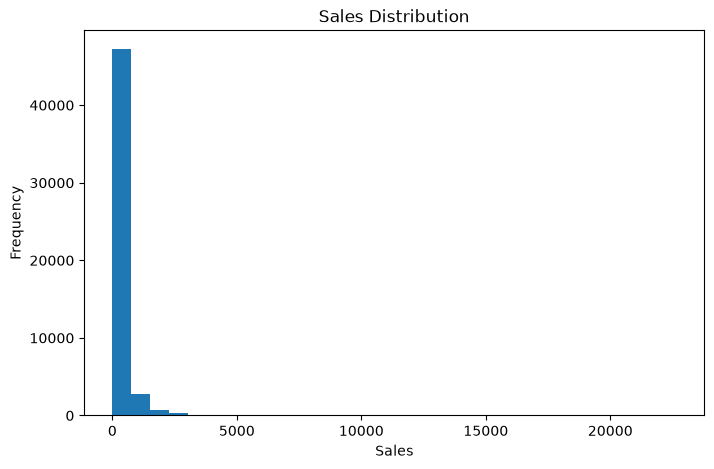

In [22]:
plt.figure(figsize=(8,5))

plt.hist(df["sales"], bins=30)

plt.title("Sales Distribution")

plt.xlabel("Sales")

plt.ylabel("Frequency")

plt.show()

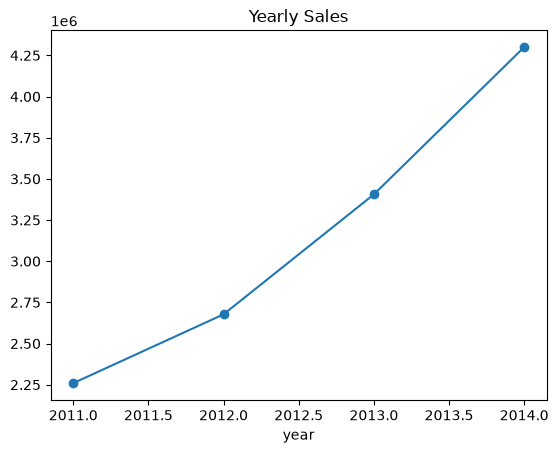

In [23]:
yearly_sales = df.groupby("year")["sales"].sum()

yearly_sales.plot(
    kind="line",
    marker="o"
)

plt.title("Yearly Sales")

plt.show()

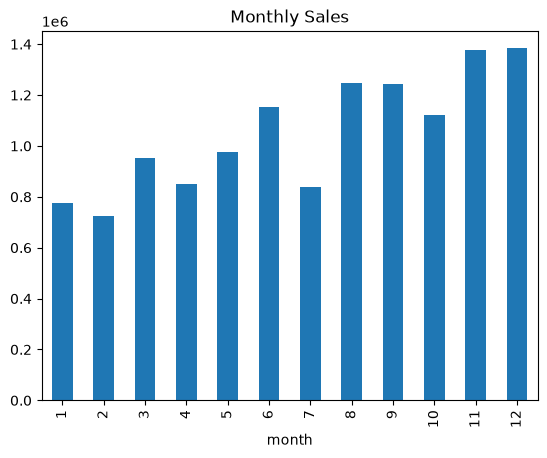

In [24]:
monthly_sales = df.groupby("month")["sales"].sum()

monthly_sales.plot(
    kind="bar"
)

plt.title("Monthly Sales")

plt.show()

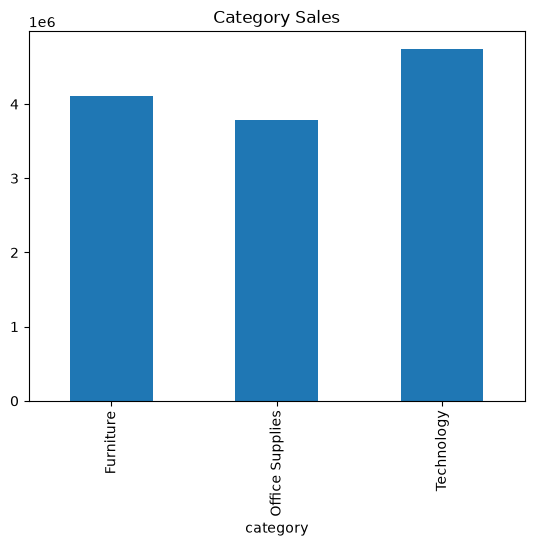

In [25]:
category_sales = df.groupby("category")["sales"].sum()

category_sales.plot(
    kind="bar"
)

plt.title("Category Sales")

plt.show()

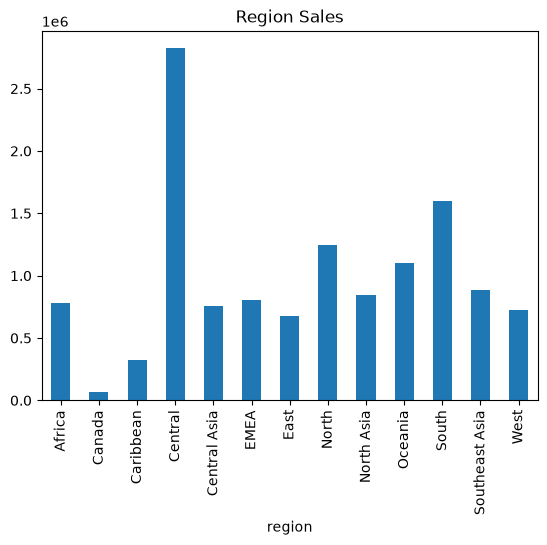

In [26]:
region_sales = df.groupby("region")["sales"].sum()

region_sales.plot(
    kind="bar"
)

plt.title("Region Sales")

plt.show()

In [27]:
features = [
    "year",
    "month",
    "quantity",
    "discount",
    "profit",
    "category",
    "region",
    "segment"
]

X = df[features]

y = df["sales"]

In [28]:
X = pd.get_dummies(
    X,
    drop_first=True
)

In [29]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

In [31]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(41032, 21)
(10258, 21)
(41032,)
(10258,)


In [32]:
df.to_csv(
    r"D:\Ai_project\AI_Sales_Prediction_Dashboard\processed_data\cleaned_data.csv",
    index=False
)

In [33]:
X_scaled_df = pd.DataFrame(
    X_scaled,
    columns=X.columns
)

X_scaled_df.to_csv(
    r"D:\Ai_project\AI_Sales_Prediction_Dashboard\processed_data\model_data.csv",
    index=False
)

In [34]:
import os

print(
    os.path.exists(
        r"D:\Ai_project\AI_Sales_Prediction_Dashboard\processed_data\cleaned_data.csv"
    )
)

print(
    os.path.exists(
        r"D:\Ai_project\AI_Sales_Prediction_Dashboard\processed_data\model_data.csv"
    )
)

True
True
